# 02 · Modeling & Evaluasi (Validation Set)



In [43]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../src')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)

from utils import RANDOM_STATE, feature_engineering, evaluate_model

np.random.seed(RANDOM_STATE)
print('Semua library berhasil di-import.')

Semua library berhasil di-import.


In [44]:
df = pd.read_csv('../data/raw/german_credit_data_updated.csv')
print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (954, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


## 5. Encoding Target & Train–Validation–Test Split

Split dilakukan **sebelum** imputasi/scaling/feature-engineering fitting apa pun,
supaya seluruh proses fitting (imputer, scaler, encoder) hanya "melihat" data train dan
tidak bocor informasi dari validation/test set (*no data leakage*).

In [45]:
# Encode target -> 0 = Good (layak), 1 = Bad (tidak layak)
df['target'] = df['Credit Risk'].map({1: 0, 2: 1})
print(df['target'].value_counts())

X = df.drop(columns=['Unnamed: 0', 'Credit Risk', 'target'])
y = df['target']

print('X shape:', X.shape)
print('y shape:', y.shape)

target
0    665
1    289
Name: count, dtype: int64
X shape: (954, 9)
y shape: (954,)


In [46]:
# 70% train, 15% validation, 15% test (stratified agar proporsi kelas terjaga)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print('X_train:', X_train.shape, ' bad-rate:', y_train.mean().round(3))
print('X_val  :', X_val.shape,   ' bad-rate:', y_val.mean().round(3))
print('X_test :', X_test.shape, ' bad-rate:', y_test.mean().round(3))

X_train: (667, 9)  bad-rate: 0.303
X_val  : (143, 9)  bad-rate: 0.301
X_test : (144, 9)  bad-rate: 0.306


## 6. Feature Engineering

Fitur turunan dibuat dengan fungsi deterministik (tidak butuh *fit* dari data), sehingga
aman diterapkan langsung ke train, validation, maupun test tanpa risiko leakage.

- **`Credit_per_Month`** = Credit amount / Duration → mengukur beban cicilan per bulan,
  proxy afordabilitas yang lebih informatif daripada jumlah kredit atau durasi sendiri-sendiri.
- **`Age_Group`** = kategori umur (Young/Adult/Senior) → menangkap pola non-linear risiko
  terhadap usia yang sulit ditangkap model linear dari `Age` mentah.
- **`Job_Skill`** = mapping kode `Job` (0-3) menjadi label kategori agar lebih mudah
  diinterpretasi (tetap ordinal secara semantik).

In [47]:
X_train_fe = feature_engineering(X_train)
X_val_fe   = feature_engineering(X_val)
X_test_fe  = feature_engineering(X_test)

X_train_fe.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit_per_Month,Age_Group,Job_Skill
889,40,male,2,rent,NaN,NaN,7824,28,car,279.428571,Adult(26-40),skilled
314,29,male,1,own,NaN,rich,1494,4,car,373.500000,Adult(26-40),unskilled_resident
700,29,female,1,rent,quite rich,NaN,1123,12,furniture/equipment,93.583333,Adult(26-40),unskilled_resident
648,38,male,2,free,little,rich,947,24,car,39.458333,Adult(26-40),skilled
651,37,male,1,own,little,moderate,1922,12,furniture/equipment,160.166667,Adult(26-40),unskilled_resident


## 7. Preprocessing Pipeline

- **Numerik** (`Age`, `Job`, `Credit amount`, `Duration`, `Credit_per_Month`): imputasi
  median (aman terhadap outlier) + `StandardScaler`.
- **Kategorikal** (`Sex`, `Housing`, `Purpose`, `Age_Group`, `Job_Skill`): imputasi modus +
  `OneHotEncoder`.
- **Kategorikal dengan missing bermakna** (`Saving accounts`, `Checking account`): imputasi
  konstanta `"none"` (bukan modus) karena kosong kemungkinan berarti "tidak punya rekening",
  lalu `OneHotEncoder`.

Semua digabung dalam satu `ColumnTransformer` yang di-*fit* hanya pada `X_train_fe`, lalu
dipakai (via `Pipeline`) untuk transform val/test — mencegah data leakage.

In [48]:
numeric_features = ['Age', 'Job', 'Credit amount', 'Duration', 'Credit_per_Month']
missing_meaningful_features = ['Saving accounts', 'Checking account']
categorical_features = ['Sex', 'Housing', 'Purpose', 'Age_Group', 'Job_Skill']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

missing_meaningful_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    ('miss', missing_meaningful_transformer, missing_meaningful_features)
])

print('Preprocessor siap.')

Preprocessor siap.


## 8. Modeling

Tiga algoritma diimplementasikan (melebihi syarat minimal 2 model) agar perbandingan
lebih kaya:

1. **Logistic Regression** — baseline linear, mudah diinterpretasi.
2. **Random Forest** — ensemble tree, menangkap interaksi non-linear.
3. **XGBoost** — gradient boosting, biasanya performa terbaik pada data tabular.

Ketiganya dibungkus dalam `Pipeline` (`preprocessor` + `classifier`) dan memakai
`class_weight='balanced'` / `scale_pos_weight` untuk mengatasi *class imbalance* yang
ditemukan di Bagian 4.

In [49]:
bad_ratio = (y_train == 0).sum() / (y_train == 1).sum()  # untuk scale_pos_weight XGBoost

models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced',
                                           random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'XGBoost': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss',
                                      scale_pos_weight=bad_ratio))
    ])
}
print('3 model pipeline siap ditraining:', list(models.keys()))

3 model pipeline siap ditraining: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 9. Hyperparameter Tuning

- **Logistic Regression** → `GridSearchCV` (ruang parameter kecil, cocok grid exhaustive).
- **Random Forest & XGBoost** → `RandomizedSearchCV` (ruang parameter besar, lebih efisien
  daripada grid search penuh).
- Semua tuning memakai **5-fold Stratified Cross Validation** pada `X_train_fe` saja,
  dengan skor **ROC-AUC** (metrik yang tepat untuk data imbalance) — validation set dan
  test set **tidak disentuh** selama tuning agar evaluasi akhir tetap objektif.

In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs', 'liblinear']
    },
    'Random Forest': {
        'classifier__n_estimators': [200, 300, 500],
        'classifier__max_depth': [4, 6, 8, 12, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'classifier__n_estimators': [200, 300, 500],
        'classifier__max_depth': [3, 4, 5, 6],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__subsample': [0.7, 0.8, 1.0],
        'classifier__colsample_bytree': [0.7, 0.8, 1.0]
    }
}

best_estimators = {}

for name, pipe in models.items():
    print(f'\n=== Tuning {name} ===')
    if name == 'Logistic Regression':
        search = GridSearchCV(pipe, param_grids[name], scoring='roc_auc', cv=cv, n_jobs=-1)
    else:
        search = RandomizedSearchCV(pipe, param_grids[name], n_iter=25, scoring='roc_auc',
                                     cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train_fe, y_train)
    best_estimators[name] = search.best_estimator_
    print(f'Best CV ROC-AUC: {search.best_score_:.4f}')
    print(f'Best params: {search.best_params_}')


=== Tuning Logistic Regression ===
Best CV ROC-AUC: 0.7463
Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

=== Tuning Random Forest ===
Best CV ROC-AUC: 0.7623
Best params: {'classifier__n_estimators': 500, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 6}

=== Tuning XGBoost ===
Best CV ROC-AUC: 0.7746
Best params: {'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}


## 10. Evaluasi & Perbandingan Model (Validation Set)

Model hasil tuning dievaluasi pada **validation set** (belum pernah dilihat model) memakai
metrik yang relevan untuk klasifikasi biner imbalanced: Accuracy, Precision, Recall,
F1-Score, dan ROC-AUC untuk kelas *Bad* (1).

In [51]:
val_results = [evaluate_model(m, X_val_fe, y_val, name) for name, m in best_estimators.items()]
comparison_df = pd.DataFrame(val_results).set_index('Model').round(4)
comparison_df.sort_values('ROC-AUC', ascending=False)

,Accuracy,Precision (Bad),Recall (Bad),F1 (Bad),ROC-AUC
Model,,,,,
Random Forest,0.7413,0.5469,0.8140,0.6542,0.8321
XGBoost,0.7483,0.5636,0.7209,0.6327,0.8112
Logistic Regression,0.7483,0.5574,0.7907,0.6538,0.7958


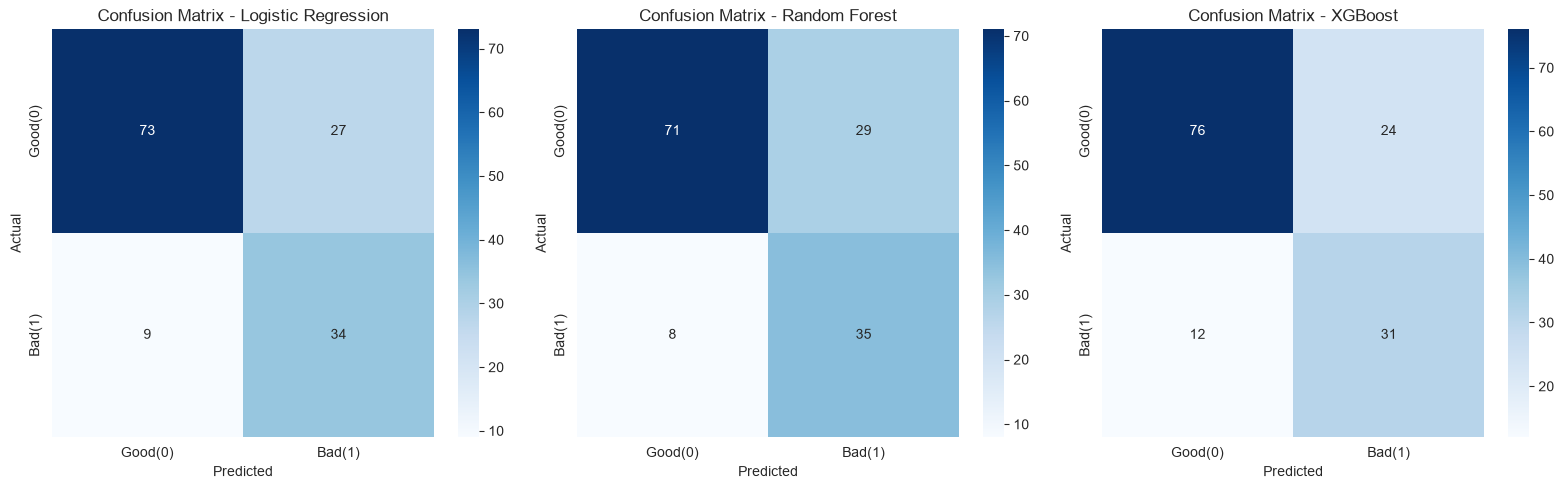

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, (name, model) in zip(axes, best_estimators.items()):
    y_pred = model.predict(X_val_fe)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Good(0)','Bad(1)'], yticklabels=['Good(0)','Bad(1)'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

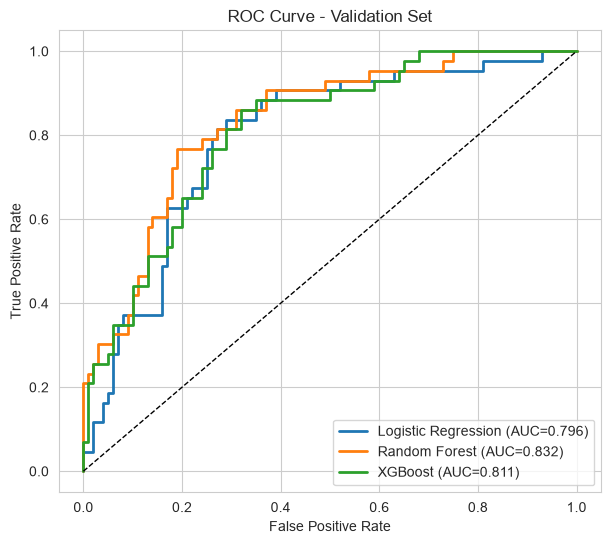

In [53]:
plt.figure(figsize=(7,6))
for name, model in best_estimators.items():
    y_prob = model.predict_proba(X_val_fe)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.show()

In [54]:
for name, model in best_estimators.items():
    print(f'\n=== Classification Report - {name} (Validation) ===')
    print(classification_report(y_val, model.predict(X_val_fe), target_names=['Good(0)','Bad(1)']))


=== Classification Report - Logistic Regression (Validation) ===
              precision    recall  f1-score   support

     Good(0)       0.89      0.73      0.80       100
      Bad(1)       0.56      0.79      0.65        43

    accuracy                           0.75       143
   macro avg       0.72      0.76      0.73       143
weighted avg       0.79      0.75      0.76       143


=== Classification Report - Random Forest (Validation) ===
              precision    recall  f1-score   support

     Good(0)       0.90      0.71      0.79       100
      Bad(1)       0.55      0.81      0.65        43

    accuracy                           0.74       143
   macro avg       0.72      0.76      0.72       143
weighted avg       0.79      0.74      0.75       143


=== Classification Report - XGBoost (Validation) ===
              precision    recall  f1-score   support

     Good(0)       0.86      0.76      0.81       100
      Bad(1)       0.56      0.72      0.63        43

  

## 11. Simpan Model & Artefak

Menyimpan seluruh model hasil tuning, model terbaik, preprocessing pipeline, ringkasan evaluasi, dan data hasil feature engineering ke `../models/` dan `../data/processed/` agar bisa dipakai kembali di `03_interpretation.ipynb`, `src/evaluate_model.py`, dan `app/app.py` tanpa perlu training ulang.

In [55]:
import joblib, os

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

best_model_name = comparison_df['ROC-AUC'].idxmax()
best_model = best_estimators[best_model_name]
print('Model terbaik (validation):', best_model_name)

joblib.dump(best_estimators, '../models/all_models.pkl')
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(best_model.named_steps['preprocessor'], '../models/preprocessing.pkl')
comparison_df.to_csv('../models/comparison_val_results.csv')

X_val_fe.to_csv('../data/processed/X_val_fe.csv', index=False)
X_test_fe.to_csv('../data/processed/X_test_fe.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print('Model & data artifacts saved.')

Model terbaik (validation): Random Forest
Model & data artifacts saved.
